# 6. 对抗性防御算法之对抗性训练（1）

## 6.0 上节内容回顾与本节主要内容介绍

在之前，我们学习了Label Smoothing防御算法、迁移攻击算法以及AutoAttack攻击算法。
我们的实验表明，Label Smoothing防御算法能够很好地防御PGD、CW等攻击，然而在面对更强力的AutoAttack时防御性能有限。这表明Label Smoothing的防御性能是脆弱的。

在本节中，我们将开始学习一种新的防御算法：对抗性训练算法。对抗性训练算法被公认为目前最有效的防御算法，在对抗性防御的benchmark robustbench(https://github.com/RobustBench/robustbench)<sup>[1]</sup> 中，排名前列的防御算法均为基于对抗性训练的防御算法。

本实验的主要内容为采用Python、PyTorch等技术，学习并实现简单的对抗性训练算法，并测试对抗性训练模型的鲁棒性。

## 6.1 导入相关模块

In [2]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 6.2 对抗性训练介绍与实现

### 6.2.0 对抗性训练介绍

对抗性训练算法与对抗性攻击算法紧密相关。如下图<sup>[2]</sup>所示，蓝色圆点与绿色原点为训练数据中的两类样本。左侧图像展示了正常训练模型所学习的分类边界（图中黑色直线）。中间图像展示了对抗性攻击产生的两个对抗性样本（红色五角星）。对抗性训练即以对抗性攻击产生的对抗性样本作为训练样本进行模型训练，右侧展示了对抗性训练得到的分类边界（图中红色曲线），能够大幅地减少对抗性样本的存在。

<div align=center>
<img src="imgs\at1.jpg"/>
</div>

下图分别展示了标准训练和对抗性训练的流程。对抗性训练与标准训练的区别在于训练时执行攻击，将原来的干净训练样本转换为对抗性样本作为新的训练样本进行训练。

<div align=center>
<img src="imgs\at2.jpg"/>
</div>

参考文献：

[1] [Croce F, Andriushchenko M, Sehwag V, et al. Robustbench: a standardized adversarial robustness benchmark[J]. arXiv preprint arXiv:2010.09670, 2020.](https://arxiv.org/abs/2010.09670)

[2] [Madry A, Makelov A, Schmidt L, et al. Towards deep learning models resistant to adversarial attacks[J]. arXiv preprint arXiv:1706.06083, 2017.](https://arxiv.org/abs/1706.06083)

### 6.2.1 使用基于FGSM的对抗性训练算法训练LeNet5

In [3]:
# 超参数
EPOCH = 50              # 训练总epoch数
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

EPSILON = 0.1           # 攻击限制
STEP_SIZE = 0.1         # 攻击步长

# 检查数据集路径是否存在以及数据集是否存在
if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [4]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [5]:
# 定义网络结构并统计模型参数
from models import LeNet5

cnn = LeNet5().to(device)
print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [6]:
"""
    对抗性训练实现
"""

train_accs = []           # 训练集干净样本准确率
train_robust_accs = []    # 训练集FGSM对抗性样本准确率
train_losses = []         # 训练集干净样本损失
train_robust_losses = []  # 训练集FGSM对抗性样本损失

test_accs = []            # 测试集干净样本准确率
test_robust_accs = []     # 测试集FGSM对抗性样本准确率
test_losses = []          # 测试集干净样本损失
test_robust_losses = []   # 测试集FGSM对抗性样本损失

for epoch in range(EPOCH):
    train_loss = 0.0
    train_robust_loss = 0.0
    train_robust_correct = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        train_total += n

        inputs, labels = inputs.to(device), labels.to(device)
        
        # 执行攻击，产生对抗性样本作为训练样本
        cnn.eval()

        inputs = inputs.requires_grad_(True)
        outputs = cnn(inputs)
        loss = loss_function(outputs, labels) * n
        grad = torch.autograd.grad(loss, inputs)[0]
        inputs = inputs + STEP_SIZE * torch.sign(grad)
        inputs = torch.clamp(inputs, max=1.0, min=0).clone().detach().requires_grad_(False)

        pred = outputs.argmax(dim=-1)
        train_loss += loss.data.item()
        train_correct += (pred == labels).sum().item()
        
        # 执行训练
        cnn.train()
        outputs = cnn(inputs)

        loss = loss_function(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.argmax(dim=1)
        train_robust_correct += (pred == labels).sum().item()      
        train_robust_loss += loss.data.item() * n  
        
    train_robust_accs.append(train_robust_correct / train_total)
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    train_robust_losses.append(train_robust_loss / train_total)
    logger.info(f'training epoch: {epoch}, clean loss: {train_loss / train_total:11.7f}, ' 
                f'robust loss: {train_robust_loss / train_total:11.7f}, '
                f'acc: {100 * train_correct / train_total:6.2f}%, '
                f'robust acc: {100 * train_robust_correct / train_total:6.2f}%')

    # 测试
    cnn.eval()
    test_loss = 0.0
    test_robust_loss = 0.0
    test_correct = 0
    test_robust_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)

            with torch.enable_grad():
                inputs = inputs.requires_grad_(True)
                outputs = cnn(inputs)
                loss = loss_function(outputs, labels)
                grad = torch.autograd.grad(loss, inputs)[0]
                inputs = inputs + STEP_SIZE * torch.sign(grad)
                inputs = torch.clamp(inputs, max=1.0, min=0).clone().detach().requires_grad_(False)

                pred = outputs.argmax(dim=-1)
                test_correct += (pred == labels).sum().item()
                test_loss += loss.data.item() * n

            outputs = cnn(inputs)
            loss = loss_function(outputs, labels)
            
            pred = outputs.argmax(dim=1)
            test_robust_loss += loss.data.item() * n
            test_robust_correct += (pred == labels).sum().item()
            test_total += n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)
    test_robust_losses.append(test_robust_loss / test_total)
    test_robust_accs.append(test_robust_correct / test_total)

    logger.info(f'    test epoch: {epoch}, clean loss: {test_loss / test_total:11.7f}, '
                f'robust loss: {test_robust_loss / test_total:11.7f}, '
                f'acc: {100 * test_correct / test_total:6.2f}%, '
                f'robust acc: {100 * test_robust_correct / test_total:6.2f}%')

 15468 20260207 12:52:17 training epoch: 0, clean loss:   0.5578351, robust loss:   0.8713965, acc:  83.12%, robust acc:  69.44%
 15468 20260207 12:52:17 training epoch: 0, clean loss:   0.5578351, robust loss:   0.8713965, acc:  83.12%, robust acc:  69.44%
 15468 20260207 12:52:19     test epoch: 0, clean loss:   0.1136691, robust loss:   0.3759717, acc:  96.63%, robust acc:  87.60%
 15468 20260207 12:52:19     test epoch: 0, clean loss:   0.1136691, robust loss:   0.3759717, acc:  96.63%, robust acc:  87.60%
 15468 20260207 12:52:36 training epoch: 1, clean loss:   0.0906951, robust loss:   0.3202745, acc:  97.37%, robust acc:  89.42%
 15468 20260207 12:52:36 training epoch: 1, clean loss:   0.0906951, robust loss:   0.3202745, acc:  97.37%, robust acc:  89.42%
 15468 20260207 12:52:38     test epoch: 1, clean loss:   0.0594819, robust loss:   0.2460845, acc:  98.24%, robust acc:  91.89%
 15468 20260207 12:52:38     test epoch: 1, clean loss:   0.0594819, robust loss:   0.2460845, ac

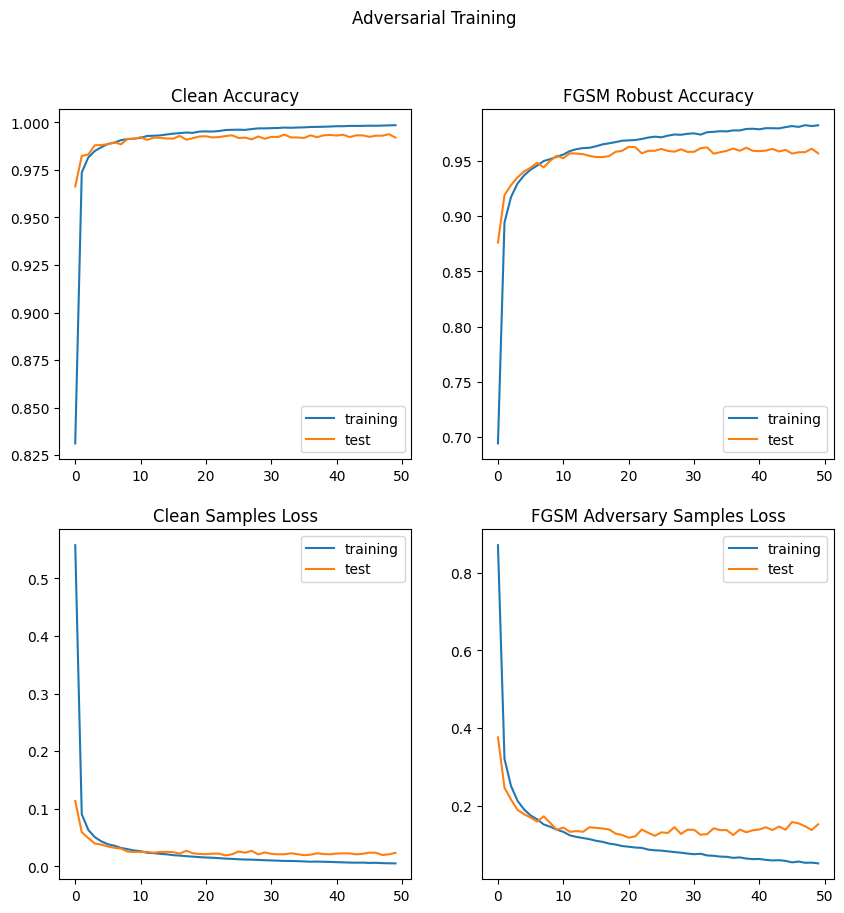

In [7]:
# 训练过程数据展示
plt.figure(figsize=(10, 10))

idx = [_ for _ in range(EPOCH)]
plt.subplot(2, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Clean Accuracy')

plt.subplot(2, 2, 2)
plt.plot(idx, train_robust_accs, label='training')
plt.plot(idx, test_robust_accs, label='test')
plt.legend()
plt.title('FGSM Robust Accuracy')

plt.subplot(2, 2, 3)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Clean Samples Loss')

plt.subplot(2, 2, 4)
plt.plot(idx, train_robust_losses, label='training')
plt.plot(idx, test_robust_losses, label='test')
plt.legend()
plt.title('FGSM Adversary Samples Loss')

plt.suptitle(f'Adversarial Training')
plt.show()

In [8]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'num_epoch': epoch,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
}

result_path = f'./save_model/' + str(EPOCH) + 'epoch'
if not os.path.isdir(result_path):
    os.makedirs(result_path)
torch.save(state, result_path + f'/mnist_lenet5_FGSM_AT.pth')

## 6.3 鲁棒性测试

### 6.3.0 白盒攻击鲁棒性测试

In [10]:
# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 加载样本
imgs, lbls = load_mnist_test()

# 执行测试
cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')                         # 干净样本
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'FGSM AT - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

 15468 20260207 13:13:22 FGSM AT - Clean: 99.20, FGSM: 95.66, PGD: 90.71, CW: 90.89
 15468 20260207 13:13:22 FGSM AT - Clean: 99.20, FGSM: 95.66, PGD: 90.71, CW: 90.89


测试标准模型作为对比

In [12]:
# 模型加载
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义攻击参数
FGSM_kwargs = dict(net=std_lenet, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 执行测试
cln_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')                         # 干净样本
fgsm_acc, _ = test_fn(nn.Sequential(FGSM, std_lenet), imgs, lbls, bs=250, mode='attack')  # FGSM
pgd_acc, _ = test_fn(nn.Sequential(PGD, std_lenet), imgs, lbls, bs=250, mode='attack')    # PGD
cw_acc, _ = test_fn(nn.Sequential(CW, std_lenet), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'Without AT - Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

 15468 20260207 13:13:48 Without AT - Clean: 99.00, FGSM: 79.45, PGD: 33.66, CW: 33.62
 15468 20260207 13:13:48 Without AT - Clean: 99.00, FGSM: 79.45, PGD: 33.66, CW: 33.62


可以看到，使用FGSM进行对抗性训练的网络鲁棒性要优于非对抗性训练的网络。

### 6.3.1 迁移攻击测试

使用标准模型作为替代模型，对对抗性训练模型进行迁移攻击。

In [13]:
# FGSM, PGD, CW 分别为替代模型的Adversary
trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

logger.info(f'Transfer Attack - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}')

 15468 20260207 13:14:00 Transfer Attack - FGSM: 98.23, PGD: 98.09, CW: 98.98
 15468 20260207 13:14:00 Transfer Attack - FGSM: 98.23, PGD: 98.09, CW: 98.98


可以看到，使用标准模型作为替代模型进行迁移攻击难以攻破对抗性训练模型。

### 6.3.2 AutoAttack测试

In [14]:
from autoattack import AutoAttack

adversary = AutoAttack(cnn, eps=0.1)

x_adv = adversary.run_standard_evaluation(imgs, lbls)

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 99.20%
apgd-ce - 1/40 - 27 out of 250 successfully perturbed
apgd-ce - 2/40 - 26 out of 250 successfully perturbed
apgd-ce - 3/40 - 32 out of 250 successfully perturbed
apgd-ce - 4/40 - 18 out of 250 successfully perturbed
apgd-ce - 5/40 - 27 out of 250 successfully perturbed
apgd-ce - 6/40 - 26 out of 250 successfully perturbed
apgd-ce - 7/40 - 28 out of 250 successfully perturbed
apgd-ce - 8/40 - 29 out of 250 successfully perturbed
apgd-ce - 9/40 - 35 out of 250 successfully perturbed
apgd-ce - 10/40 - 26 out of 250 successfully perturbed
apgd-ce - 11/40 - 30 out of 250 successfully perturbed
apgd-ce - 12/40 - 22 out of 250 successfully perturbed
apgd-ce - 13/40 - 24 out of 250 successfully perturbed
apgd-ce - 14/40 - 26 out of 250 successfully perturbed
apgd-ce - 15/40 - 28 out of 250 successfully perturbed
apgd-ce - 16/40 - 26 out of 250 successfully perturbed

在上一节中，我们测得标准模型的AutoAttack准确率约为17%；Label Smoothing模型的AutoAttack准确率约为8%。相比之下，FGSM AT模型的AutoAttack准确率能达到85%（AutoAttack具有一定随机性，因此结果略有波动）。因此，FGSM AT具有更好的鲁棒性。